In [1]:
pip install pandas matplotlib openpyxl notebook

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the modules that were installed
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('Ready!')

Ready!


In [3]:
# Load the Dataset
df = pd.read_csv('diabetes.csv')
print('Dataset is loaded successfully!')

Dataset is loaded successfully!


In [4]:
# Check the shape of the dataset
print(f"Dataset has {df.shape[0]} rows has {df.shape[1]}")
print(df.columns.tolist())

Dataset has 768 rows has 9
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe().round()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,4.0,121.0,69.0,21.0,80.0,32.0,0.0,33.0,0.0
std,3.0,32.0,19.0,16.0,115.0,8.0,0.0,12.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.0,0.0,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.0,32.0,0.0,29.0,0.0
75%,6.0,140.0,80.0,32.0,127.0,37.0,1.0,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.0,2.0,81.0,1.0


In [8]:
# Show which column value is missing and how many cells
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_data = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing %', ascending=False)

# A condition to print the columns with missing values, if any, or to proceed if clean
if missing_data.sum().sum() > 0:
    print('Columns where values are missing:')
    print(missing_data.to_string())
else:
    print('Data is clean proceed with analysis!')

Data is clean proceed with analysis!


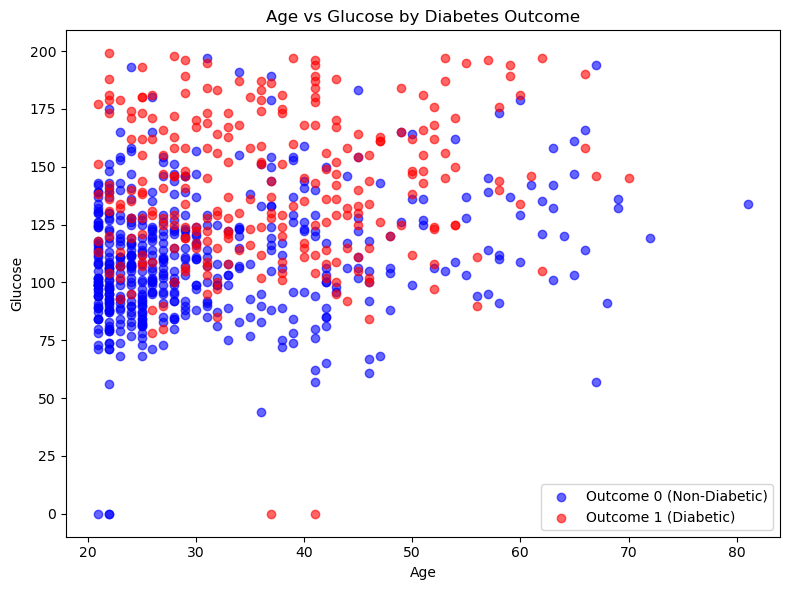

In [9]:
plt.figure(figsize=(8,6))

# Outcome 0 (Non‑Diabetic)
plt.scatter(
    df[df['Outcome'] == 0]['Age'],
    df[df['Outcome'] == 0]['Glucose'],
    color='blue',
    label='Outcome 0 (Non-Diabetic)',
    alpha=0.6
)

# Outcome 1 (Diabetic)
plt.scatter(
    df[df['Outcome'] == 1]['Age'],
    df[df['Outcome'] == 1]['Glucose'],
    color='red',
    label='Outcome 1 (Diabetic)',
    alpha=0.6
)

plt.xlabel('Age')
plt.ylabel('Glucose')
plt.title('Age vs Glucose by Diabetes Outcome')
plt.legend()
plt.tight_layout()
plt.show()